# Geometry Learning Curves

This notebook mirrors `learning_curves.ipynb` but is scoped to geometry logs aggregated from `tutor_gym/sandbox/geometry/log_al`.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from os.path import exists

from pyafm.roll_up import transaction_to_student_step


In [6]:
DEFAULT_OPP_COUNT_CUTOFF = 5
DEFAULT_OPP_CUTOFF = -1
domain_max_opp_counts = {}

def load_rollup(base_filename, do_clean=False, force_rerollup=False, inp_delim='	', **kwargs):
    if do_clean:
        raise ValueError('This notebook expects pre-cleaned DataShop transactions. Use do_clean=False.')

    rollup_filename = base_filename[:-4] + '-rollup.txt'
    if force_rerollup or not exists(rollup_filename):
        with open(base_filename, encoding='utf-8') as f:
            transaction_to_student_step(f)
    return pd.read_csv(rollup_filename, sep='	')

def load_kc_opp_counts(base_filename, kc_model='field', **kwargs):
    df = load_rollup(base_filename, **kwargs)

    kc_counts = {}
    for (stu, kc), sub_df in df.groupby(['Anon Student Id', f'KC ({kc_model})']):
        L = len(sub_df)
        if kc not in kc_counts:
            kc_counts[kc] = {
                'correct_counts': np.zeros(L),
                'total_counts': np.zeros(L),
            }

        cnts = kc_counts[kc]
        correct_counts = cnts['correct_counts']
        total_counts = cnts['total_counts']

        if L > len(total_counts):
            correct_counts = np.pad(correct_counts, (0, L - len(correct_counts)))
            total_counts = np.pad(total_counts, (0, L - len(total_counts)))

        correct_counts[:L] += np.array(sub_df['First Attempt'] == 'correct')
        total_counts[:L] += 1

        kc_counts[kc] = {
            'correct_counts': correct_counts,
            'total_counts': total_counts,
        }

    return kc_counts

def aggregate_curves(kc_curves):
    max_len = max(len(arr) for arr in kc_curves.values())
    padded_curves = [np.pad(arr, (0, max_len - len(arr))) for arr in kc_curves.values()]
    return np.sum(padded_curves, axis=0) / len(padded_curves)

def counts_to_curves(kc_counts, opp_count_cutoff=DEFAULT_OPP_COUNT_CUTOFF, opp_cutoff=DEFAULT_OPP_CUTOFF, **kwargs):
    kc_curves = {}
    for kc, cnts in kc_counts.items():
        corr, tots = cnts['correct_counts'], cnts['total_counts']
        bad_indices = np.where(tots < opp_count_cutoff)[0]
        max_opp = bad_indices[0] if len(bad_indices) > 0 else len(corr)

        if opp_cutoff != -1:
            max_opp = min(opp_cutoff, max_opp)

        domain = kc.split('--')[0] if '--' in kc else 'geometry'
        domain_max_opp_counts[domain] = max(domain_max_opp_counts.get(domain, 0), max_opp)

        if max_opp == 0:
            continue

        err_curve = 1.0 - (corr / tots)
        kc_curves[kc] = err_curve[:max_opp]

    return aggregate_curves(kc_curves), kc_curves

def load_curves(base_filename, **kwargs):
    kc_counts = load_kc_opp_counts(base_filename, **kwargs)
    return counts_to_curves(kc_counts, **kwargs)


In [7]:
def plot_curves(models, ylim=(-0.02, 1.02), xlim=None, title='Learning Curves'):
    plt.figure(figsize=(6, 4))

    for model_name, (curve, kwargs) in models.items():
        if curve is not None:
            plt.plot(np.arange(0, len(curve)) + 1, curve, linewidth=2, **kwargs, label=model_name)

    plt.grid()
    plt.title(title, size=14)
    plt.legend()
    if ylim:
        plt.ylim(*ylim)
    if xlim:
        plt.xlim(*xlim)
    plt.xlabel('Number of Learning Opportunities', size=12)
    plt.ylabel('Average Error Rate', size=12)
    plt.show()

def plot_top_kc_curves(kc_curves, top_n=10):
    ordered = sorted(kc_curves.items(), key=lambda kv: len(kv[1]), reverse=True)[:top_n]
    for kc, curve in ordered:
        plot_curves({kc: (curve, {'marker': 'o'})}, title=f'KC: {kc}', ylim=(-0.02, 1.02))


In [8]:
BASE_FILE = 'geometry_log_al_aggregated.txt'

agg_geom_curve, kc_geom_curves = load_curves(
    BASE_FILE,
    do_clean=False,
    inp_delim='	',
    opp_count_cutoff=0,
    opp_cutoff=15,
)

print(f'Aggregate curve length: {len(agg_geom_curve)}')
print(f'KCs: {len(kc_geom_curves)}')
print(f'Max opp by domain: {domain_max_opp_counts}')


Aggregate curve length: 15
KCs: 16
Max opp by domain: {'geometry': 15}


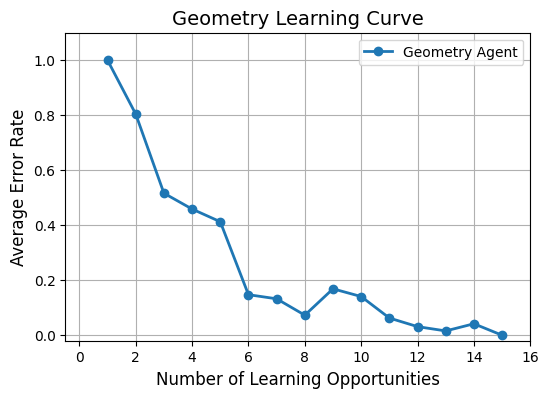

In [12]:
plot_curves({
    'Geometry Agent': (agg_geom_curve, {'marker': 'o'})
}, title='Geometry Learning Curve', ylim=(-0.02, 1.1), xlim=(-0.5, 16))


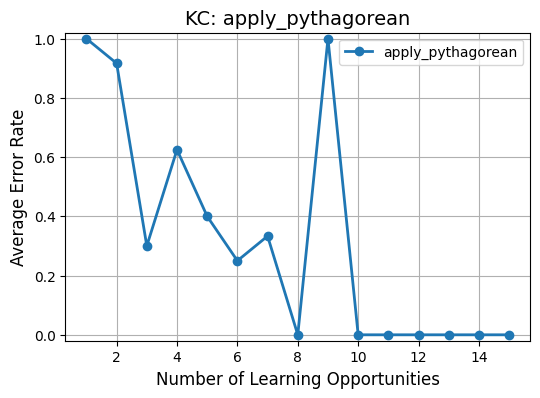

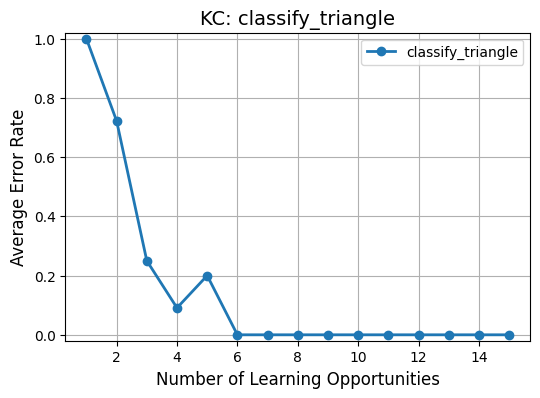

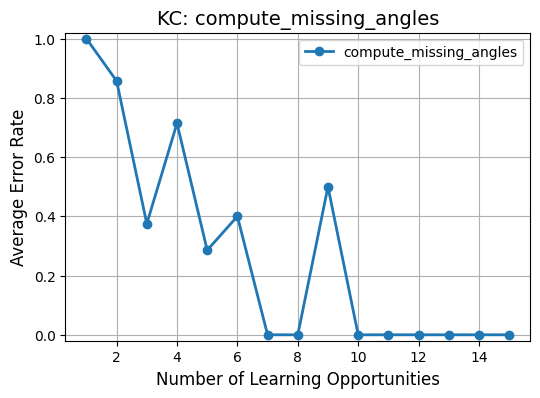

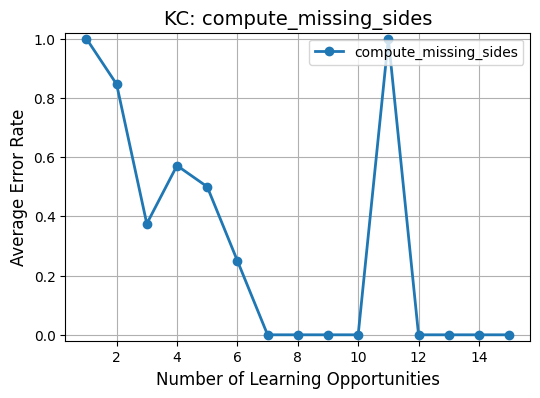

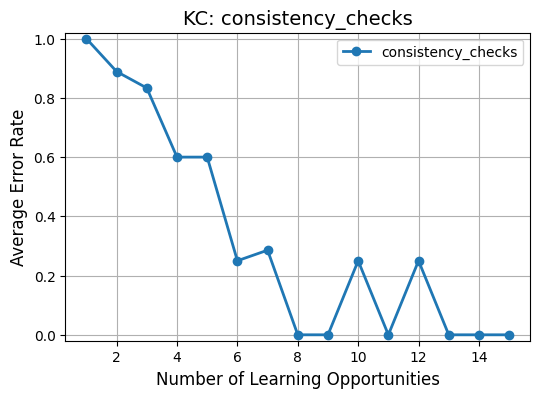

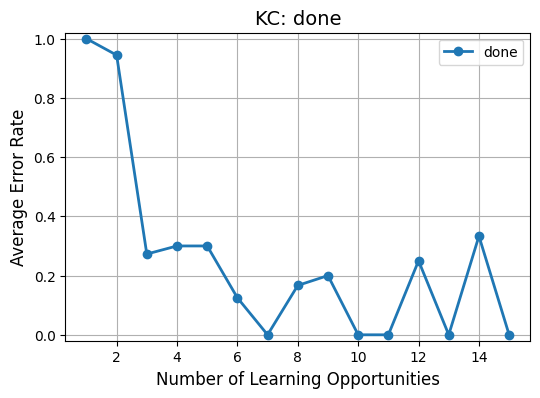

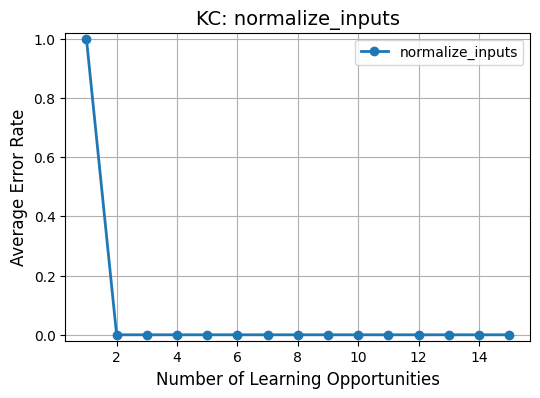

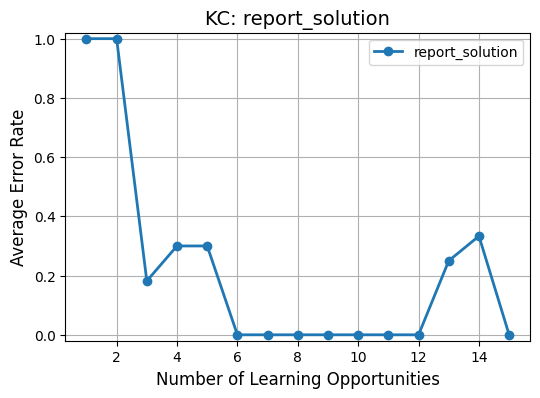

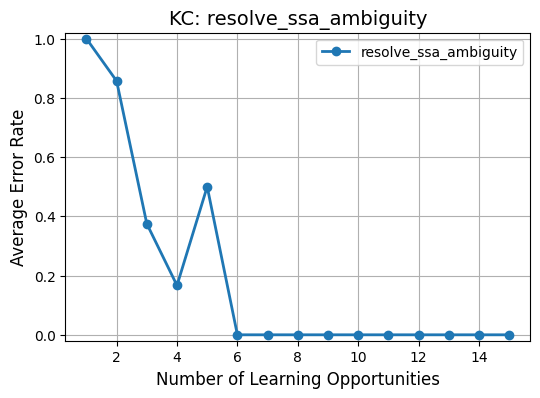

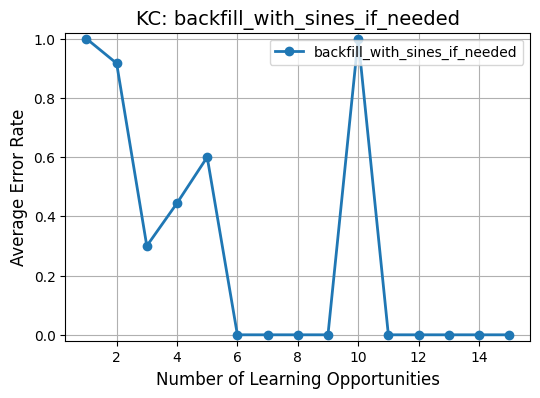

In [10]:
# Optional: plot the top-K KC curves by number of opportunities
plot_top_kc_curves(kc_geom_curves, top_n=10)
